In [1]:
!pip install shap

   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/41.9 MB ? eta -:--:--
    --------------------------------------- 0.5/41.9 MB 1.9 MB/s eta 0:00:23
   - -------------------------------------- 1.0/41.9 MB 2.1 MB/s eta 0:00:20
   - -------------------------------------- 1.6/41.9 MB 2.2 MB/s eta 0:00:18
   -- ------------------------------------- 2.4/41.9 MB 2.5 MB/s eta 0:00:16
   --- ------------------------------------ 3.1/41.9 MB 2.7 MB/s eta 0:00:15
   --- ------------------------------------ 3.9/41.9 MB 2.9 MB/s eta 0:00:14
   ---- ----------------------------------- 4.7/41.9 MB 3.0 MB/s eta 0:00:13
   ----- ---------------------------------- 5.8/41.9 MB 3.3 MB/s eta 0:00:12
   ------ --------------------------------- 6.8/41.9 MB 3.5 MB/s eta 0:00:11
   ------- -------------------------------- 7.9/41.9 MB 3.7 MB/s eta 0:00:10
   -------- ------------------------------- 9.2/41.9 MB 3.9 MB/s eta 0:00:09
   ----------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLEANED_PATH = r"C:\glassIDS\data\processed\cicids2017_cleaned.csv"
df = pd.read_csv(CLEANED_PATH)

feature_cols = [c for c in df.columns if c not in ("Label", "is_attack", "source_file", "Destination Port")]
X = df[feature_cols]
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# reload the saved preprocessing objects
le = joblib.load(r"C:\glassIDS\models\label_encoder.joblib")
scaler = joblib.load(r"C:\glassIDS\models\scaler.joblib")

y_test_enc = le.transform(y_test)
X_test_scaled = scaler.transform(X_test)  # only the neural models need this

# reload XGBoost
xgb_model = XGBClassifier()
xgb_model.load_model(r"C:\glassIDS\models\xgboost_baseline.json")

print(X_test.shape, X_test_scaled.shape)
print(list(le.classes_))
print(xgb_model.predict(X_test.iloc[:5]))

(504160, 77) (504160, 77)
['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - Sql Injection', 'Web Attack - XSS']
[ 0 10  0  0  0]


In [3]:
class SimpleMLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )
    def forward(self, x):
        return self.net(x)

class SimpleCNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.relu = nn.ReLU()
        pooled_length = input_size // 2
        self.fc1 = nn.Linear(32 * pooled_length, 64)
        self.fc2 = nn.Linear(64, num_classes)
    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.flatten(start_dim=1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

mlp_model = SimpleMLP(input_size=X_test.shape[1], num_classes=len(le.classes_)).to(device)
mlp_model.load_state_dict(torch.load(r"C:\glassIDS\models\mlp_model.pt", map_location=device))
mlp_model.eval()

cnn_model = SimpleCNN(input_size=X_test.shape[1], num_classes=len(le.classes_)).to(device)
cnn_model.load_state_dict(torch.load(r"C:\glassIDS\models\cnn_model.pt", map_location=device))
cnn_model.eval()

print(mlp_model)
print(cnn_model)

SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=77, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=15, bias=True)
  )
)
SimpleCNN(
  (conv1): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=1216, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=15, bias=True)
)


In [4]:
import shap

SAMPLE_PER_CLASS = 300

sample_indices = []
for cls in np.unique(y_test_enc):
    cls_indices = np.where(y_test_enc == cls)[0]
    n = min(len(cls_indices), SAMPLE_PER_CLASS)
    chosen = np.random.RandomState(42).choice(cls_indices, size=n, replace=False)
    sample_indices.extend(chosen)

sample_indices = np.array(sample_indices)
X_shap_sample = X_test.iloc[sample_indices]
y_shap_sample = y_test_enc[sample_indices]

print(X_shap_sample.shape)
print(pd.Series(y_shap_sample).value_counts().sort_index())

(3437, 77)
0     300
1     300
2     300
3     300
4     300
5     300
6     300
7     300
8       2
9       7
10    300
11    300
12    294
13      4
14    130
Name: count, dtype: int64


In [5]:
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_shap_sample)

print(type(shap_values_xgb))
if isinstance(shap_values_xgb, list):
    print(len(shap_values_xgb), shap_values_xgb[0].shape)
else:
    print(shap_values_xgb.shape)

<class 'numpy.ndarray'>
(3437, 77, 15)


Plotting for class index 1: Bot


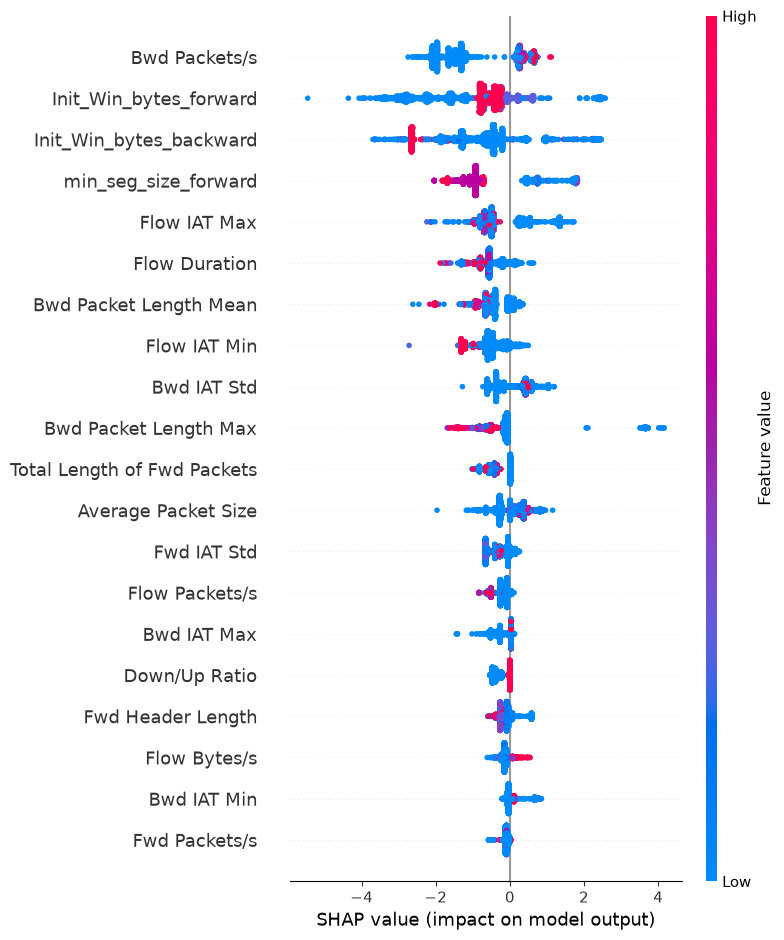

In [6]:
class_idx = list(le.classes_).index("Bot")
print(f"Plotting for class index {class_idx}: {le.classes_[class_idx]}")

shap.summary_plot(
    shap_values_xgb[:, :, class_idx],
    X_shap_sample,
    show=True
)

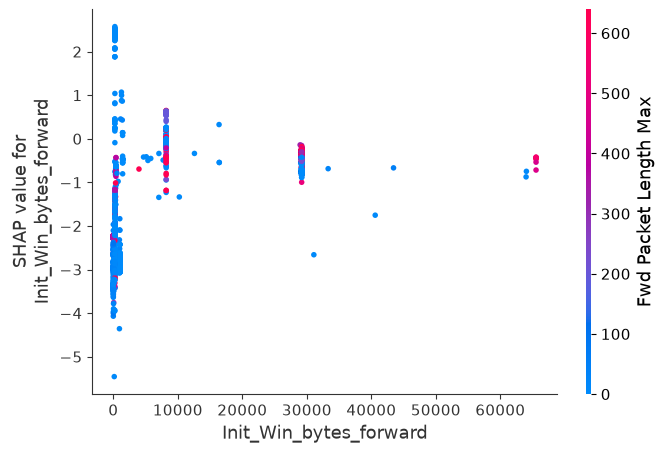

In [7]:
shap.dependence_plot(
    "Init_Win_bytes_forward",
    shap_values_xgb[:, :, class_idx],
    X_shap_sample,
    interaction_index="auto",
    show=True
)

Plotting for class index 14: Web Attack - XSS


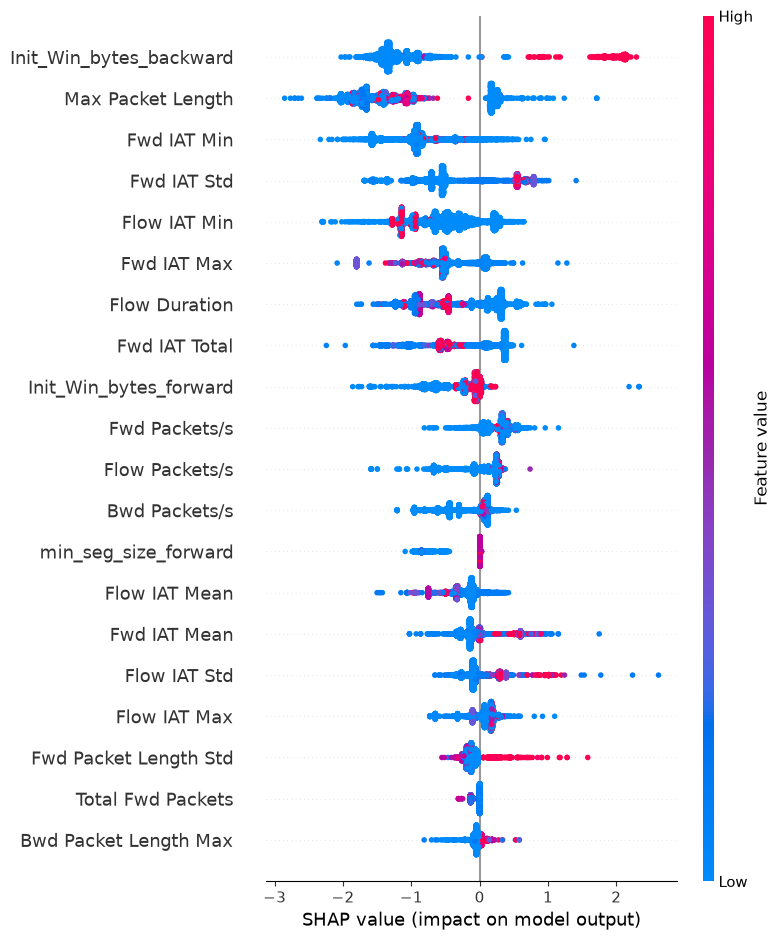

In [8]:
class_idx = list(le.classes_).index("Web Attack - XSS")
print(f"Plotting for class index {class_idx}: {le.classes_[class_idx]}")

shap.summary_plot(
    shap_values_xgb[:, :, class_idx],
    X_shap_sample,
    show=True
)

Plotting for class index 12: Web Attack - Brute Force


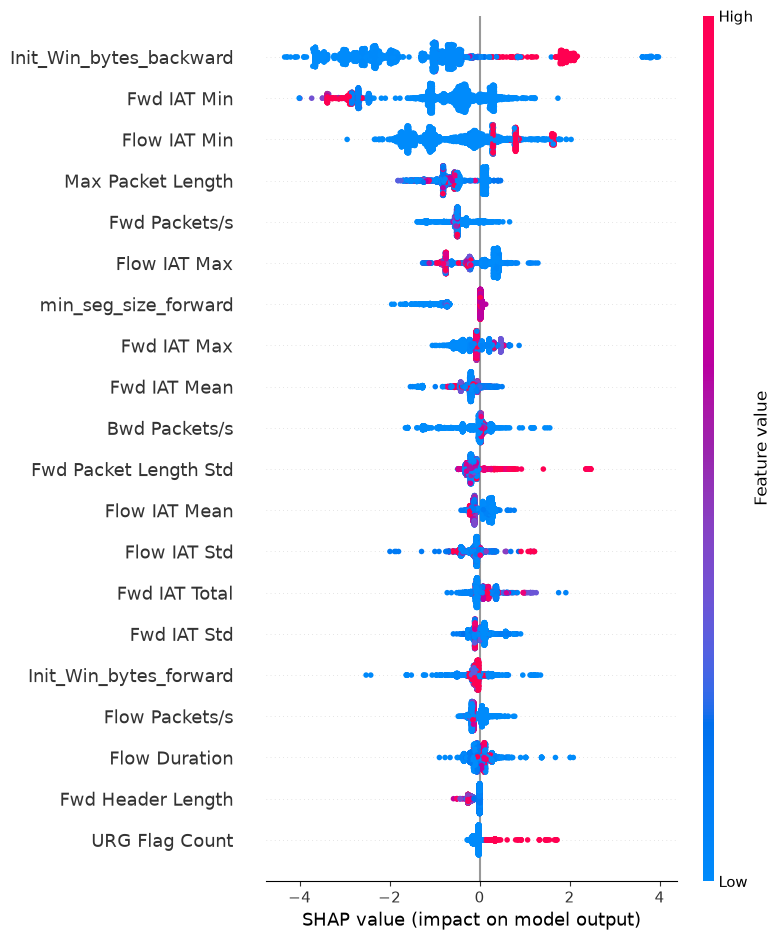

In [9]:
class_idx = list(le.classes_).index("Web Attack - Brute Force")
print(f"Plotting for class index {class_idx}: {le.classes_[class_idx]}")

shap.summary_plot(
    shap_values_xgb[:, :, class_idx],
    X_shap_sample,
    show=True
)

In [10]:
X_shap_sample_scaled = scaler.transform(X_shap_sample)
X_shap_tensor = torch.tensor(X_shap_sample_scaled, dtype=torch.float32).to(device)

# DeepExplainer needs a smaller "background" reference set to estimate a baseline expectation
background = X_shap_tensor[:100]

explainer_mlp = shap.DeepExplainer(mlp_model, background)
shap_values_mlp = explainer_mlp.shap_values(X_shap_tensor)

print(type(shap_values_mlp))
if isinstance(shap_values_mlp, list):
    print(len(shap_values_mlp), shap_values_mlp[0].shape)
else:
    print(shap_values_mlp.shape)

<class 'numpy.ndarray'>
(3437, 77, 15)


Plotting for class index 1: Bot


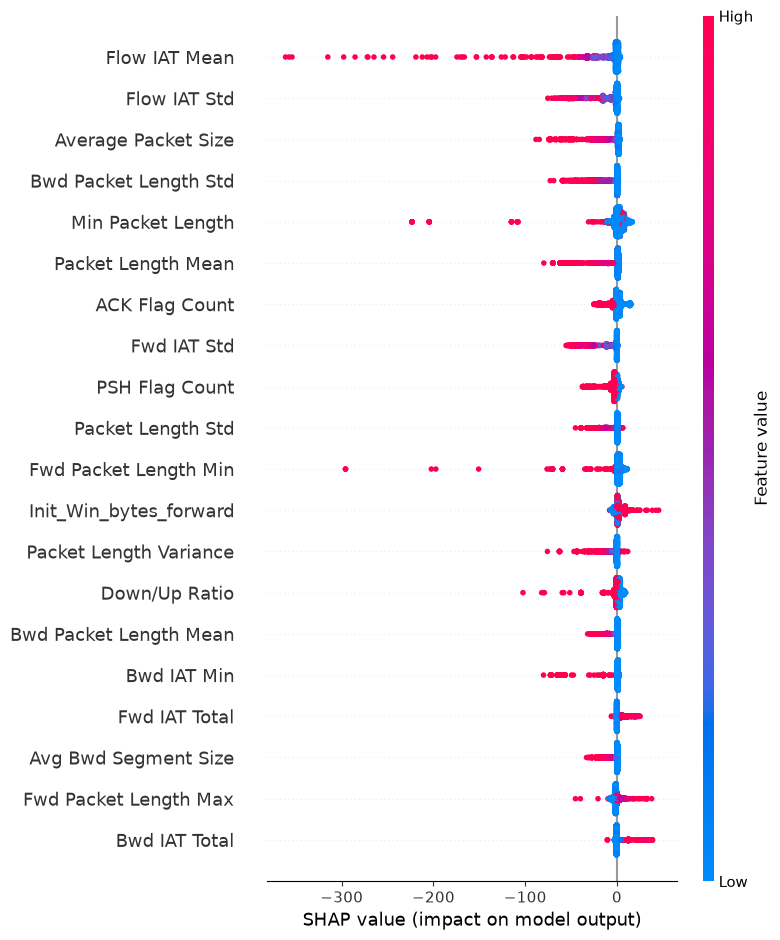

In [11]:
class_idx = list(le.classes_).index("Bot")
print(f"Plotting for class index {class_idx}: {le.classes_[class_idx]}")

shap.summary_plot(
    shap_values_mlp[:, :, class_idx],
    X_shap_sample,
    show=True
)

In [13]:
class SimpleCNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()
        self.relu3 = nn.ReLU()
        pooled_length = input_size // 2
        self.fc1 = nn.Linear(32 * pooled_length, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = self.pool(x)
        x = x.flatten(start_dim=1)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

cnn_model = SimpleCNN(input_size=X_test.shape[1], num_classes=len(le.classes_)).to(device)
cnn_model.load_state_dict(torch.load(r"C:\glassIDS\models\cnn_model.pt", map_location=device))
cnn_model.eval()

SimpleCNN(
  (conv1): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu1): ReLU()
  (relu2): ReLU()
  (relu3): ReLU()
  (fc1): Linear(in_features=1216, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=15, bias=True)
)

In [14]:
explainer_cnn = shap.DeepExplainer(cnn_model, background)
shap_values_cnn = explainer_cnn.shap_values(X_shap_tensor)

print(type(shap_values_cnn))
if isinstance(shap_values_cnn, list):
    print(len(shap_values_cnn), shap_values_cnn[0].shape)
else:
    print(shap_values_cnn.shape)

<class 'numpy.ndarray'>
(3437, 77, 15)


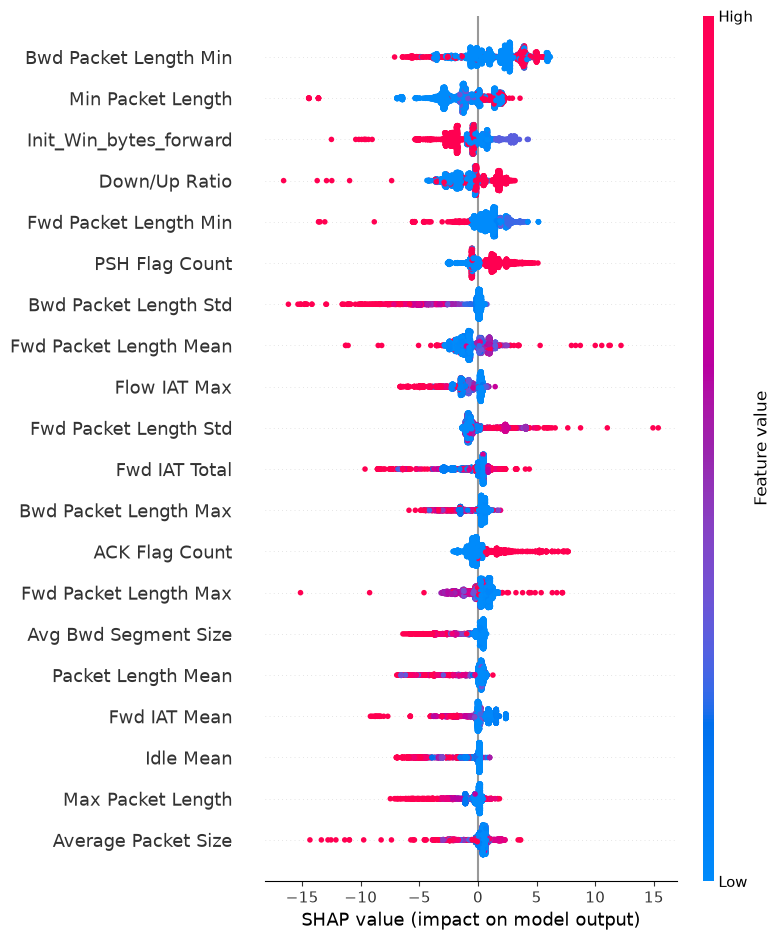

In [15]:
class_idx = list(le.classes_).index("Bot")

shap.summary_plot(
    shap_values_cnn[:, :, class_idx],
    X_shap_sample,
    show=True
)

In [16]:
bot_idx = list(le.classes_).index("Bot")
benign_idx = list(le.classes_).index("BENIGN")

xgb_test_preds = xgb_model.predict(X_test)
false_bot_mask = (y_test_enc == benign_idx) & (xgb_test_preds == bot_idx)
false_bot_positions = np.where(false_bot_mask)[0]

print(f"Found {len(false_bot_positions)} BENIGN-as-Bot false positives in the full test set")

example_row = X_test.iloc[[false_bot_positions[0]]]
print(example_row)

Found 397 BENIGN-as-Bot false positives in the full test set
        Flow Duration  Total Fwd Packets  Total Backward Packets  \
266790        1012768                  3                       3   

        Total Length of Fwd Packets  Total Length of Bwd Packets  \
266790                            0                           18   

        Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
266790                      0                      0                     0.0   

        Fwd Packet Length Std  Bwd Packet Length Max  ...  act_data_pkt_fwd  \
266790                    0.0                      6  ...                 0   

        min_seg_size_forward  Active Mean  Active Std  Active Max  Active Min  \
266790                    28          0.0         0.0           0           0   

        Idle Mean  Idle Std  Idle Max  Idle Min  
266790        0.0       0.0         0         0  

[1 rows x 77 columns]


(1, 77, 15)


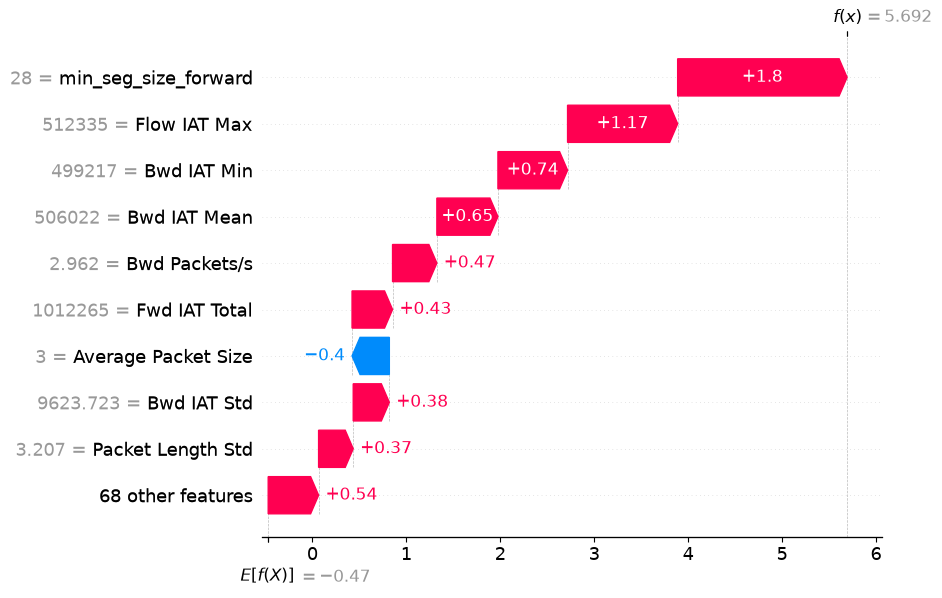

In [17]:
explanation = explainer_xgb(example_row)
print(explanation.shape)

shap.plots.waterfall(explanation[0, :, bot_idx], show=True)